#**Classification binaire avec un réseau de neurones**

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


17/17 - 2s - 93ms/step - accuracy: 0.4451 - loss: 0.7060 - val_accuracy: 0.4675 - val_loss: 0.6990
Epoch 2/100
17/17 - 0s - 6ms/step - accuracy: 0.5680 - loss: 0.6915 - val_accuracy: 0.5974 - val_loss: 0.6833
Epoch 3/100
17/17 - 0s - 8ms/step - accuracy: 0.6574 - loss: 0.6783 - val_accuracy: 0.6753 - val_loss: 0.6687
Epoch 4/100
17/17 - 0s - 8ms/step - accuracy: 0.6965 - loss: 0.6662 - val_accuracy: 0.7013 - val_loss: 0.6540
Epoch 5/100
17/17 - 0s - 8ms/step - accuracy: 0.7169 - loss: 0.6539 - val_accuracy: 0.7013 - val_loss: 0.6395
Epoch 6/100
17/17 - 0s - 8ms/step - accuracy: 0.7318 - loss: 0.6411 - val_accuracy: 0.7273 - val_loss: 0.6228
Epoch 7/100
17/17 - 0s - 8ms/step - accuracy: 0.7374 - loss: 0.6267 - val_accuracy: 0.7403 - val_loss: 0.6051
Epoch 8/100
17/17 - 0s - 9ms/step - accuracy: 0.7449 - loss: 0.6105 - val_accuracy: 0.7532 - val_loss: 0.5847
Epoch 9/100
17/17 - 0s - 6ms/step - accuracy: 0.7467 - loss: 0.5927 - val_accuracy: 0.7792 - val_loss: 0.5626
Epoch 10/100
17/17 - 

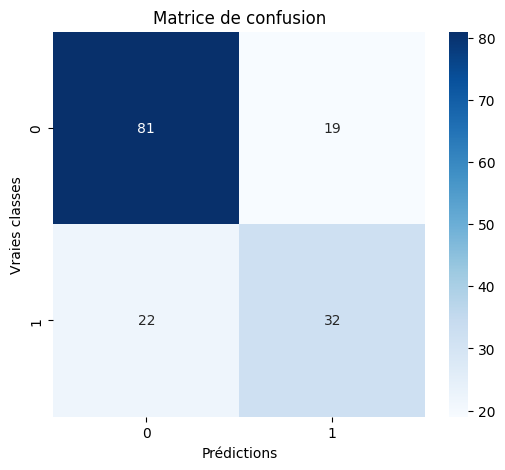

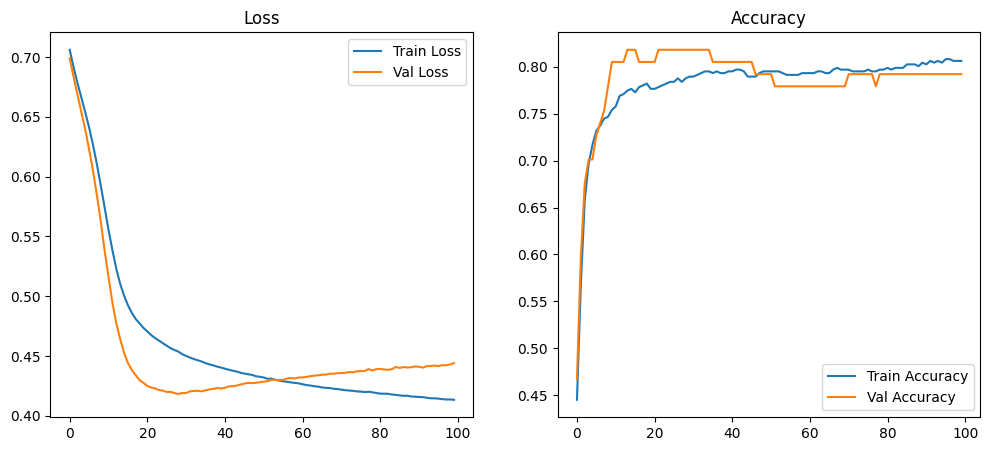

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('diabetes.csv')
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    median = data.loc[data[col] != 0, col].median()
    data.loc[data[col] == 0, col] = median

X = data.drop('Outcome', axis=1).values
y = data['Outcome'].values

# Standardisation
mean = X.mean(axis=0)
std = X.std(axis=0)
X = (X - mean) / std

# Division train, validation, test (80-10-10)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42)

#modèle Keras
layer_sizes = [X_train.shape[1], 8, 8, 1]

model = models.Sequential([
    layers.InputLayer(input_shape=(layer_sizes[0],)),
    layers.Dense(layer_sizes[1], activation='relu',
                 kernel_regularizer=regularizers.l2(0.0002)),
    layers.Dense(layer_sizes[2], activation='relu',
                 kernel_regularizer=regularizers.l2(0.0002)),
    layers.Dense(layer_sizes[3], activation='sigmoid')
])

#Compilation du modèle
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entraînement
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=2
)

#Évaluation test
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

#Prédictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nRapport de classification (Test set) :")
print(classification_report(y_test, y_pred))

#Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion")
plt.xlabel("Prédictions")
plt.ylabel("Vraies classes")
plt.show()

#Courbes de perte et  accuracy
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(history.history['loss'], label='Train Loss')
axs[0].plot(history.history['val_loss'], label='Val Loss')
axs[0].set_title('Loss')
axs[0].legend()

axs[1].plot(history.history['accuracy'], label='Train Accuracy')
axs[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axs[1].set_title('Accuracy')
axs[1].legend()

plt.show()
